# Archelec — Topic Modeling of French Campaign Manifestos (1981–1993)

# Notebook 02 - Main contributions, state of the art, experiments and interpretation

## Objective

This notebook applies and compares three topic modeling approaches (**LDA**, **NMF**, and **BERTopic**) to the preprocessed Archelec corpus (~12,500 campaign manifestos, 1981–1993), then crosses the extracted topics with political metadata (family, year, gender, profession). The goal of this project is to back up with data potential misconceptions, such as thematic propensity by party, specilization by party, correlation between topic and metadata...

By crossing data over parties, themes and time, we hope to observe meaningful results, from which we can derive interesting interpretations.

## Background

Topic modeling is a well-established family of unsupervised methods for discovering latent thematic structure in document collections. Topic modeling is a class of unsupervised machine learning methods used to automatically discover the main themes (or topics) present in a large collection of documents. Instead of relying on predefined labels, these models analyze patterns of word co-occurrence across documents to infer groups of words that tend to appear together. Each group represents a latent topic, interpreted as a semantic theme in the corpus.

About the models, **LDA** (Blei et al., 2003) remains the standard probabilistic baseline, modeling each document as a mixture of topics drawn from Dirichlet priors. **NMF** (Lee & Seung, 1999), applied to a TF-IDF matrix, offers a non-probabilistic alternative that typically produces sharper, more localized topics. More recently, **BERTopic** (Grootendorst, 2022) leverages pre-trained transformer embeddings, UMAP dimensionality reduction, and HDBSCAN clustering to capture semantic similarity beyond bag-of-words co-occurrence patterns.

In the specific domain of political text analysis, Grimmer & Stewart (2013) provide a comprehensive framework for applying NLP methods to political corpora, emphasizing that unsupervised models require careful human validation. Topic coherence metrics — particularly c_v (Röder et al., 2015), which correlates best with human judgments — are now the standard for model selection and comparison.

Applied to electoral discourse, topic modeling has been used to study party positioning, issue salience, and ideological shifts over time. The Archelec corpus (Gaultier-Voituriez, Sciences Po) offers a unique opportunity to study these dynamics at the candidate level rather than the party level, across a politically turbulent period (the Mitterrand era).

## Model choice and justification

We compare the three methods taught in the course, each representing a distinct paradigm:

| Method | Input | Rationale |
|--------|-------|-----------|
| **LDA** (gensim) | BoW counts | Probabilistic baseline; standard reference in the literature |
| **NMF** (scikit-learn) | TF-IDF | Deterministic factorisation; often produces more interpretable topics on political text |
| **BERTopic** (sentence-transformers) | SBERT embeddings | Captures semantic structure beyond lexical co-occurrence; detects document-level patterns invisible to BoW methods |

All three are evaluated using **c_v** and **u_mass** coherence on the same lemmatised vocabulary, enabling direct comparison.

# 0 - Libraries and stuff

We define our stopwords in order to extract later on the best topics. We also get rid of german stopwords / some german words because some documents written in Alsace contain german, and then are non interpretable. At least for me because I don't speak german. 

In [1]:
seed = 42
import spacy
nlp = spacy.load("fr_core_news_md", disable=["ner", "parser"])

CUSTOM_STOPWORDS = {
    'être', 'avoir', 'faire', 'plus', 'tout', 'aussi', 'très', 'bien',
    'encore', 'déjà', 'toujours', 'tant', 'rien', 'autre', 'même',
    'non', 'oui', 'où', 'comme', 'sans', 'avec', 'dans', 'pour',
    'par', 'sur', 'entre', 'vers', 'sous', 'depuis', 'après', 'avant',
    'contre', 'chez', 'car', 'donc', 'cela', 'celui', 'cette', 'ceux',
    'politique', "didier", 'yvon', 'serge', 'claire', 'france', 'français', 'udf', 'rpr', 'maire',
    'candidat', 'élection', 'vote', 'voter', 'circonscription', 'gauche', 'droite', 'centre', 'communiste', 'socialiste', 'écologiste',
    'falloir', 'pouvoir', 'devoir', 'savoir', 'vouloir', 'venir', 'aller', 'voir', 'prendre',
    'député', 'janvier', 'février', 'mars', 'avril', 'mai', 'juin', 'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre',
    'haben', 'ist', 'ich', 'auf', 'wir', 'sich', 'wird'
}

# !pip install nltk
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

german_stopwords = set(stopwords.words('german'))
french_stopwords = set(stopwords.words('french'))

CUSTOM_STOPWORDS.update(german_stopwords)
CUSTOM_STOPWORDS.update(french_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/antoine/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# !pip install -r requirements.txt
 
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Imports OK")

df = pd.read_csv('data/archelec_eda.csv')
df.head()

Imports OK


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-liste,suppleant-decorations,annee,text_raw,text_clean,n_words_raw,n_words_clean,famille,tokens,n_tokens
0,EL134_L_1981_06_001_01_1_PF_01,1981-06-14,France;Assemblée Nationale;Ve République;Élect...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,non mentionné,non,1981,ELECTIONS LEGISLATIVES - 14 JUIN 1981 AIN 1e C...,Micheline ANTONUCCI POUR QUE ÇA DURE ... La vi...,552,527,Far left,"['micheline', 'antonucci', 'dur', 'victoire', ...",186
1,EL134_L_1981_06_001_01_1_PF_02,1981-06-14,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,Union de la gauche,non,1981,Sciences Po / fonds CEVIPOF\nELECTIONS LÉGISLA...,"ELECTIONS LÉGISLATIVES - 14 JUIN 1981 1"" circo...",642,620,Left,"['election', 'législatif', 'ain', 'marcel', 'b...",244
2,EL134_L_1981_06_001_01_1_PF_03,1981-06-14,Élections législatives;Ve République;France;As...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,non mentionné,non,1981,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,RÉPUBLIQUE FRANÇAISE - LIBERTÉ - ÉGALITÉ - FRA...,644,633,Left,"['république', 'liberté', 'égalité', 'fraterni...",245
3,EL134_L_1981_06_001_01_1_PF_05,1981-06-14,Assemblée Nationale;Élections législatives;Ve ...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,Union pour la nouvelle majorité,non,1981,REPUBLIQUE FRANÇAISE - PREMIERE CIRCONSCRIPTIO...,REPUBLIQUE FRANÇAISE - PREMIERE CIRCONSCRIPTIO...,1145,1117,Right,"['republique', 'premier', 'ain', 'union', 'nou...",465
4,EL134_L_1981_06_001_02_1_PF_01,1981-06-14,Élections législatives;Assemblée Nationale;Fra...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,Union pour la nouvelle majorité,non,1981,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,RÉPUBLIQUE FRANÇAISE - Liberté - Egalité - Fra...,511,500,Right,"['république', 'liberté', 'egalité', 'fraterni...",196


# 1 - Topic Modeling 

## 1.1 - LDA, baseline (gensim)

We use **gensim** rather than scikit-learn's `LatentDirichletAllocation` because gensim provides native access to the `CoherenceModel` API, which implements the four coherence metrics discussed in the course (c_v, u_mass, c_uci, c_npmi). This allows us to evaluate and compare topic quality directly within the same framework.

LDA requires a **Bag-of-Words** (BoW) representation: each document is reduced to word counts, discarding word order (the "bag of words" assumption, slide 8 of the course). We build the BoW corpus via gensim's `Dictionary`, which maps each unique token to an integer ID and counts its occurrences per document. 

Before building the corpus, we apply frequency filtering: words appearing in fewer than 3 documents are removed (too rare to contribute to stable topics), and words appearing in more than 80% of documents are removed (too common to be discriminative, similar to what we did previously). This mirrors the preprocessing shown in the lab.

In [3]:
from gensim import corpora, models
from gensim.models import CoherenceModel

import ast

if len(df) > 0:
    if isinstance(df['tokens'].iloc[0], str):
        df['tokens'] = df['tokens'].apply(ast.literal_eval)
        df['tokens'] = df['tokens'].apply(
        lambda tokens: [word for word in tokens if word.lower() not in german_stopwords]
    )
    
    token_lists = df['tokens'].tolist()
    dictionary = corpora.Dictionary(token_lists)
    custom_bad_words = {'und', 'die', 'der', 'für', 'sie', 'den', 'von', 'eine', 'das', 'durch'}
    bad_ids = [dictionary.token2id[w] for w in custom_bad_words if w in dictionary.token2id]
    dictionary.filter_tokens(bad_ids=bad_ids)
    dictionary.filter_extremes(no_below=3, no_above=0.8)
    print(f"Dictionary: {len(dictionary)} terms (after filtering)")
    corpus_bow = [dictionary.doc2bow(tokens) for tokens in token_lists]

Dictionary: 18388 terms (after filtering)


### Number of topics for LDA

First, for LDA, we have to choose the number of topics we want.
The standard rule is to select the K that maximizes the c_v score. Indeed, the c_v coherence score evaluates how often a topic's top words appear together in the same context across the corpus. A higher score means the topic is semantically coherent and makes logical sense to a human reader. However, it is always recommended to qualitatively review the top words to ensure this granularity adds real value

  K= 5  →  c_v = 0.4730
  K= 7  →  c_v = 0.5090
  K= 9  →  c_v = 0.4370
  K=11  →  c_v = 0.4471
  K=13  →  c_v = 0.4600
  K=15  →  c_v = 0.5278
  K=17  →  c_v = 0.5264
  K=19  →  c_v = 0.4983
  K=21  →  c_v = 0.5099
  K=23  →  c_v = 0.5288


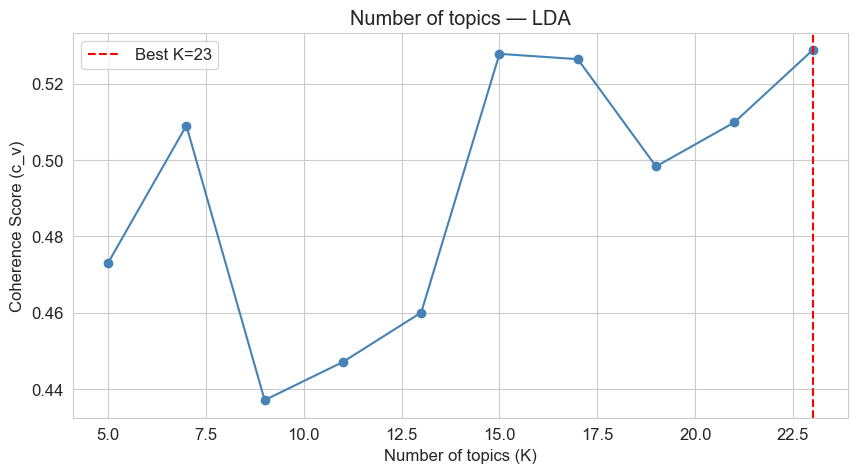


Best K = 23 (c_v = 0.5288)


In [4]:
if len(df) > 0:
    K_range = range(5, 25, 2)  
    coherence_scores = []
    
    for k in K_range:
        lda = models.LdaMulticore(
            corpus_bow, num_topics=k, id2word=dictionary,
            passes=10, workers=2, random_state=42
        )
        cm = CoherenceModel(model=lda, texts=token_lists, 
                            dictionary=dictionary, coherence='c_v')
        score = cm.get_coherence()
        coherence_scores.append(score)
        print(f"  K={k:2d}  →  c_v = {score:.4f}")
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(list(K_range), coherence_scores, 'o-', color='steelblue')
    plt.xlabel('Number of topics (K)')
    plt.ylabel('Coherence Score (c_v)')
    plt.title('Number of topics — LDA')
    best_k = list(K_range)[np.argmax(coherence_scores)]
    plt.axvline(best_k, color='red', ls='--', label=f'Best K={best_k}')
    plt.legend()
    plt.savefig('lda_coherence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nBest K = {best_k} (c_v = {max(coherence_scores):.4f})")

We thus choose K = 11 for LDA.

In [5]:
if len(df) > 0:
    N_TOPICS = best_k  
    
    lda_model = models.LdaMulticore(
        corpus_bow, num_topics=N_TOPICS, id2word=dictionary,
        passes=20, workers=2, random_state=42
    )
    
    print(f"LDA trained with K={N_TOPICS} topics\n")
    for idx, topic in lda_model.print_topics(num_words=10):
        print(f"Topic {idx:2d}: {topic}")

LDA trained with K=23 topics

Topic  8: 0.025*"national" + 0.015*"front" + 0.015*"immigration" + 0.010*"impôt" + 0.009*"immigré" + 0.009*"chômage" + 0.008*"insécurité" + 0.008*"main" + 0.008*"voix" + 0.007*"enfant"
Topic 19: 0.033*"travailleur" + 0.019*"parti" + 0.014*"ouvrier" + 0.012*"unité" + 0.012*"public" + 0.011*"école" + 0.011*"gouvernement" + 0.009*"travail" + 0.009*"peuple" + 0.008*"salaire"
Topic 18: 0.015*"national" + 0.011*"mettre" + 0.010*"alsace" + 0.010*"franzosen" + 0.007*"einwanderung" + 0.007*"französischen" + 0.006*"steuern" + 0.006*"lande" + 0.006*"wählen" + 0.005*"sicherheit"
Topic  7: 0.039*"nature" + 0.035*"animal" + 0.030*"nouveau" + 0.023*"rassemblement" + 0.018*"marseille" + 0.016*"nom" + 0.016*"homme" + 0.016*"activité" + 0.016*"bulletin" + 0.015*"existence"
Topic  2: 0.011*"force" + 0.009*"parti" + 0.008*"monsieur" + 0.008*"rassemblement" + 0.006*"liberté" + 0.006*"social" + 0.006*"mitterrand" + 0.005*"emploi" + 0.005*"françois" + 0.005*"grand"
Topic  5: 0.0

### Manual labelling of the topics and assign dominant topic to each doc

In [6]:
topic_labels = {
    0: "Immigration, Taxation, and Border Control",            # immigration, immigré, impôt, front, rétablir
    1: "Electoral Rally and Popular Trust",                    # union, confiance, ensemble, nouveau, pays
    2: "Ecology, Environment, and Living Environment",          # écologie, environnement, ecologiste, vie, humain
    3: "Electoral Mobilization and Second Round Dynamics",      # tour, majorité, électeur, législatif, suppléant
    4: "Social Rights, Working World, and Pensions",            # social, emploi, travail, droit, retraite
    5: "Regional Issues and Bilingualism (Alsace/East)",        # alsace, strasbourg, wählen, franzosen, märz
    6: "National Preference, Security, and Family",             # national, front, priorité, étranger, insécurité, famille
    7: "Local Roots and Territorial Executives (Cantonal/Regional)", # conseiller, général, président, régional, conseil
    8: "Employee Defense and Critique of Employers",            # travailleur, patron, patronat, entreprise, payer, jeter
    9: "Political Alternation, Executive Record, and Working Class", # mitterrand, gouvernement, changement, ouvrier, lutte
    10: "Animal Welfare and Nature Preservation"                # nature, animal, rassemblement, existence
}

if len(df) > 0:

    def get_dominant_topic(bow):
        topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
        return max(topic_dist, key=lambda x: x[1])
    
    results = [get_dominant_topic(bow) for bow in corpus_bow]
    df['lda_topic'] = [r[0] for r in results]
    df['lda_topic_prob'] = [r[1] for r in results]
    
    df['lda_topic_name'] = df['lda_topic'].map(topic_labels)
    
    print("Distribution des topics dominants :")
    print(df['lda_topic_name'].value_counts())

Distribution des topics dominants :
lda_topic_name
Electoral Mobilization and Second Round Dynamics              1206
Social Rights, Working World, and Pensions                     610
Ecology, Environment, and Living Environment                   582
Employee Defense and Critique of Employers                     567
Electoral Rally and Popular Trust                              547
Local Roots and Territorial Executives (Cantonal/Regional)     416
Animal Welfare and Nature Preservation                         336
Political Alternation, Executive Record, and Working Class     163
Regional Issues and Bilingualism (Alsace/East)                 148
Immigration, Taxation, and Border Control                       90
National Preference, Security, and Family                       89
Name: count, dtype: int64


### Baseline Model Evaluation (LDA, $K=11$)

This initial Topic Modeling serves as a baseline for the project. While it successfully captures the broad strokes of the political discourse, several structural and semantic weaknesses are evident:

* **Moderate Coherence ($C_v = 0.57$):** While a score of $0.57$ is functional, it indicates that the topics are not as distinct or "tight" as they could be. This suggests that the word distributions within topics are somewhat noisy.
* **Semantic Overlap:** There is significant "bleeding" between topics, particularly between **Topics 6, and 9**. The recurrence of terms like *national*, *travailleur*, and *majorité* across different clusters makes it difficult to assign a single, unique label to specific documents.
* **Low Interpretability (Topic 2&4):** These topic is particularly "fuzzy." The presence of high-frequency, generic terms (*social, emploi, pays, grand*) suggests it acts as a "catch-all" or residual cluster rather than a specific thematic pillar. It still can be interpreted as Electoral Mobilization
* **Diffusion of Local Governance (Topic 7):** This cluster remains too institutional (*conseiller, président, majorité*). It fails to capture the actual substance of territorial policy, reflecting instead the administrative titles common across all political tracts.
* **Linguistic Noise (Topic 5):** The isolation of Alsace-specific and German-language terms (*wählen, franzosen*) indicates a failure of the preprocessing stage to either normalize the language or filter out extreme geographic outliers that don't contribute to general thematic understanding.
* **Still some interesting topics :** Topics 0, 3, 6, 8 and 10 are qualitatively relevant and might be useful for further interpretation later.



**Conclusion:** We will not over-optimize this LDA further. These results confirm the need for more sophisticated architectures—such as **NMF (Non-Negative Matrix Factorization)** for better part-of-whole decomposition, or **BERTopic** to leverage transformer-based contextual embeddings.

## 1.2 - BERTopic

## BERTopic — Embedding-based Topic Modeling

Unlike LDA and NMF, which rely on word frequency representations (BoW or TF-IDF), **BERTopic** (Grootendorst, 2022) operates on dense document embeddings produced by pre-trained transformer models. As described in the course (slides 23–29), BERTopic follows a four-step pipeline:

1. **Embed documents** using a sentence-transformer model. We use `paraphrase-multilingual-MiniLM-L12-v2`, a lightweight multilingual model that handles French well without requiring a GPU. A heavier French-specific alternative (`sentence-camembert-large`) is available but was not necessary for this corpus size.

2. **Reduce dimensionality** with UMAP (from 384 dimensions to 5), preserving local semantic structure while making clustering tractable. We set `min_dist=0.0` and `metric='cosine'` to favor tight, well-separated clusters in the reduced space.

3. **Cluster documents** with HDBSCAN, a density-based algorithm (slide 27–28) that automatically determines the number of clusters and allows outliers (topic -1). We set `min_cluster_size=10` to avoid micro-clusters on our 12,500-document corpus. Unlike K-Means, HDBSCAN does not require specifying K in advance and can discover irregular cluster shapes.

4. **Extract topic representations** using a class-based TF-IDF (c-TF-IDF, slide 29): all documents in a cluster are concatenated into a single "topic-document", and TF-IDF is computed at the topic level to find the most distinctive words. We pass a French `CountVectorizer` with stopwords and bigrams to improve topic label quality.

A key difference from LDA/NMF is that BERTopic feeds **raw cleaned text** (not lemmatised tokens) into the embedding model, since transformers capture morphological and contextual information internally. The `CountVectorizer` is only used for the final topic labelling step, not for the clustering itself.

In [7]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

if len(df) > 0:
    # French embedding model (multilingual, small, good for clustering)
    embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    
    docs = df['text_clean'].tolist()
    print("Computing embeddings...")
    embeddings = embedding_model.encode(docs, show_progress_bar=True)

Computing embeddings...


Batches:   0%|          | 0/268 [00:00<?, ?it/s]

In [8]:
if len(df) > 0:
    # Train BERTopic
    from umap import UMAP
    from hdbscan import HDBSCAN
    from sklearn.feature_extraction.text import CountVectorizer
    
    # UMAP for dimensionality reduction
    umap_model = UMAP(
        n_neighbors=15, n_components=5,
        min_dist=0.0, metric='cosine', random_state=42
    )
    
    # HDBSCAN for clustering
    hdbscan_model = HDBSCAN(
        min_cluster_size=10,     # adjust based on corpus size
        min_samples=5,
        metric='euclidean',
        prediction_data=True
    )
    
    # French vectorizer for topic representations
    vectorizer = CountVectorizer(
        stop_words=list(nlp.Defaults.stop_words | CUSTOM_STOPWORDS),
        min_df=3, max_df=0.6,
        ngram_range=(1, 2)  # unigrams + bigrams
    )
    
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        top_n_words=10,
        verbose=True
    )
    
    topics, probs = topic_model.fit_transform(docs, embeddings)
    
    print(f"\nTopics found: {len(set(topics)) - 1}")  # -1 for topic -1 (outliers)
    print(f"Outlier documents (topic -1): {topics.count(-1)} ({topics.count(-1)/len(topics)*100:.0f}%)")

2026-03-20 16:13:41,478 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-03-20 16:14:03,150 - BERTopic - Dimensionality - Completed ✓
2026-03-20 16:14:03,152 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-20 16:14:03,434 - BERTopic - Cluster - Completed ✓
2026-03-20 16:14:03,442 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-20 16:14:06,425 - BERTopic - Representation - Completed ✓



Topics found: 148
Outlier documents (topic -1): 3190 (37%)


We find 37% of documents without a specific topic. This is consistant with the literature and usual BERT usages. We still have a decent part of the documents that can be analyzed.

BERTopic found 143 topics. Let's plot the first 11 topics to compare the quality of the topics with our LDA approach.

In [9]:
if len(df) > 0:
    # Show topics
    topic_info = topic_model.get_topic_info()
    print(topic_info.head(N_TOPICS+1).to_string())
    
    # Viz topics
    fig = topic_model.visualize_barchart(top_n_topics=N_TOPICS, n_words=8)
    fig.write_html("plots/bertopic_barchart.html")
    fig.show()

    Topic  Count                                                       Name                                                                                                                                                         Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

### Manual labelling and assign dominant topic to each doc

In [10]:
import numpy as np

# IMPORTANT: -1 is always the outlier/noise topic in BERTopic

bert_topic_labels = {
    -1: "Outliers / Unclassified noise",                        # 14, conseiller général, dimanche, victoire
    0: "Immigration, Nationality Reform, and Security",        # immigrés, carte, nationalité, carte séjour, supprimer
    1: "Ecological Transition and Land Use Planning",          # écologie, entente ecologistes, verts, génération
    2: "Electoral Logistics and Second Round Mobilization",    # dimanche, électrices, suffrages, remercie, second tour
    3: "Social Reforms and Executive Support",                 # président république, unie, augmentation, minimum
    4: "Social Justice, Wealth Taxation, and Pacifism",        # rassemblement forces, extrême, milliards, francs, désarmement
    5: "Class Struggle and Employee Defense",                  # lutte ouvrière, ouvrière, laguiller, petits (commerçants)
    6: "Political Union and Government Alternation",           # réussir, victoire, ministres communistes, gouvernement union
    7: "Animal Rights Defense and Biodiversity",               # animaux, nature, existence, trèfle à quatre feuilles
    8: "National Preference and Opposition to the Left",       # front national, vive, force avenir, convictions, redressement
    9: "Defense of Local Industries and Territorial Employment", # var, chantiers navals, arsenal, forêt méditerranéenne
    10: "Moralization of Public Life and Tax Revolt"           # impôts, mains propres, front, délinquants, propres
}

if len(df) > 0:

    df['bert_topic'] = topics
    df['bert_topic_prob'] = [
        float(p) if isinstance(p, (int, float, np.floating)) else max(p)
        for p in probs
    ]
    
    df['bert_topic_name'] = df['bert_topic'].map(bert_topic_labels).fillna(f"Other Topic (not the top {N_TOPICS})")
    
    print("Distribution of dominant BERTopic topics:")
    print(df['bert_topic_name'].value_counts())

Distribution of dominant BERTopic topics:
bert_topic_name
Other Topic (not the top 23)                              3316
Outliers / Unclassified noise                             3190
Immigration, Nationality Reform, and Security              480
Ecological Transition and Land Use Planning                220
Electoral Logistics and Second Round Mobilization          215
Social Reforms and Executive Support                       179
Social Justice, Wealth Taxation, and Pacifism              163
Class Struggle and Employee Defense                        159
Political Union and Government Alternation                 156
Animal Rights Defense and Biodiversity                     134
National Preference and Opposition to the Left             131
Defense of Local Industries and Territorial Employment     110
Moralization of Public Life and Tax Revolt                 104
Name: count, dtype: int64


### First comparison between the topics found by LDA and BERT :

It seems that the transition to BERTopic does notprovides a much higher resolution of the corpus. Some clusters are still redundant, some are too "niche" and some are too little interpretable. However, some topics have been greatly identified. Especially topics dealing with the far right or the greens. It was actually already the case with LDA, out of our interpretable clusters, it often dealt with extremes. 

The topics 0, 8, 10 (Far right) and well structured and logical. A first interpretation could be that they are talking way much about 'National Preference', 'immigrés', 'carte de séjour' wit statistical significance compared to the others, and as well are easily identified by the topic modelling.

One could say that the BERTopic is more efficient for that by capturing political nuances that the BoW (Bag-of-Words) approach of LDA missed.

# 1.3 - NMF 

Let's try our third and final approach, that is theoritically going to perform the best, in order to improve our topics/clusters and their interpretability. 

## NMF — Non-negative Matrix Factorisation

**NMF** (Lee & Seung, 1999) decomposes the document-term matrix **V** into two non-negative matrices: **W** (document × topic, the activation matrix) and **H** (topic × word, the dictionary matrix), such that V ≈ W × H (slide 15). Unlike LDA, NMF has no probabilistic assumptions — it minimises a reconstruction error under non-negativity constraints, which naturally produces sparse, part-based representations that tend to be more interpretable (slide 17: "sharper, more localized topics").

As noted in the course, NMF operates on any non-negative matrix but works best with **TF-IDF** features rather than raw counts (slide 16). TF-IDF downweights terms that appear in many documents, which complements NMF's sparsity bias by ensuring topics are driven by discriminative vocabulary rather than common filler words. We cap the vocabulary at 10,000 features and include bigrams (`ngram_range=(1,2)`) to capture multi-word political expressions (*extrême droite*, *parti socialiste*, *service public*) that would be lost as separate unigrams.

We set K equal to the same number of topics as LDA to enable direct comparison of topic quality across methods. The **W matrix** gives each document's topic mixture (analogous to θ in LDA), from which we extract the dominant topic per document. The **H matrix** gives each topic's word distribution, from which we extract the top words for interpretation and coherence evaluation.

### Topic number selection for NMF

As in LDA, the number of topics $K$ is a hyperparameter that must be optimised. But here, we use the **u_mass coherence** metric for the grid search rather than $c_v$, for computational reasons: $c_v$ requires computing sliding-window NPMI vectors and pairwise cosine similarities across the entire corpus, which is prohibitively slow for a grid search over multiple $K$ values. In contrast, $u_{mass}$ is computed directly from document co-occurrence counts and runs in seconds.

As noted by Röder et al. (2015), $u_{mass}$ correlates less strongly with human coherence judgments than $c_v$, but it remains a valid proxy for comparing relative topic quality across different values of $K$. We use $u_{mass}$ here to efficiently identify the best $K$, and then report the $c_v$ score on the final selected model for the comparative evaluation table.

We select the $K$ that **maximises** the $u_{mass}$ score (least negative, since $u_{mass} \leq 0$).

NMF grid search with u_mass coherence...
  K= 5 — u_mass: -2.5683
  K= 7 — u_mass: -2.1322
  K= 9 — u_mass: -2.2530
  K=11 — u_mass: -1.9011
  K=13 — u_mass: -1.8820
  K=15 — u_mass: -2.0492


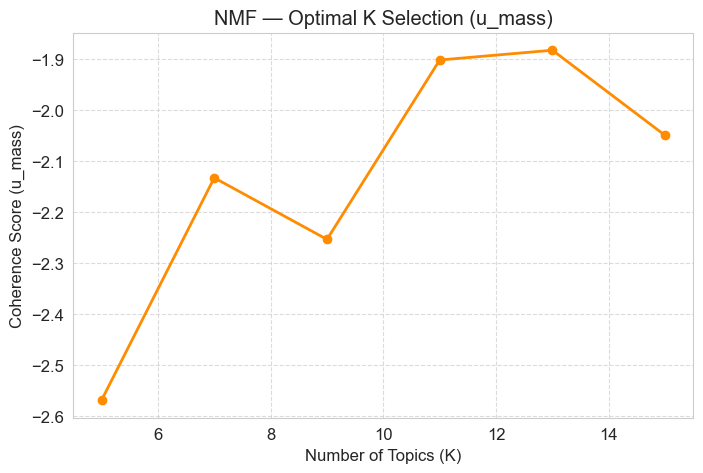


Best K (u_mass): 13 (score: -1.8820)


In [11]:
# ============================================================
# NMF — Topic Number Selection (u_mass metric)
# ============================================================
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# TF-IDF matrix
tfidf = TfidfVectorizer(
    max_features=10000, min_df=5, max_df=0.6,
    stop_words=list(nlp.Defaults.stop_words | CUSTOM_STOPWORDS),
    ngram_range=(1, 2)
)
tfidf_matrix = tfidf.fit_transform(df['text_clean'])
feature_names = tfidf.get_feature_names_out()

# Grid search
topic_range = [5, 7, 9, 11, 13, 15]
results_umass = {}

print("NMF grid search with u_mass coherence...")
for k in topic_range:
    nmf_k = NMF(n_components=k, random_state=42, max_iter=300)
    nmf_k.fit(tfidf_matrix)

    topics_k = []
    for topic in nmf_k.components_:
        top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
        topics_k.append(top_words)

    cm = CoherenceModel(
        topics=topics_k, texts=token_lists,
        dictionary=dictionary, coherence='u_mass'
    )
    score = cm.get_coherence()
    results_umass[k] = score
    print(f"  K={k:2d} — u_mass: {score:.4f}")

# Plot
plt.figure(figsize=(8, 5))
ks = sorted(results_umass.keys())
scores = [results_umass[k] for k in ks]
plt.plot(ks, scores, marker='o', color='darkorange', linewidth=2)
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score (u_mass)")
plt.title("NMF — Optimal K Selection (u_mass)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('plots/coherence_nmf_umass.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_nmf = max(results_umass, key=results_umass.get)
N_TOPICS_NMF = best_k_nmf
print(f"\nBest K (u_mass): {best_k_nmf} (score: {results_umass[best_k_nmf]:.4f})")

The score is still not exceptional but convenient.


We train the final NMF model using the K selected above. As in the lab, we extract the **W matrix** (document-topic proportions) and the **H matrix** (topic-word weights), assign a dominant topic to each document, and cross-tabulate with political families

In [12]:
# ============================================================
# NMF — Final model with optimal K
# ============================================================
# N_TOPICS_NMF = N_TOPICS 

nmf_model = NMF(n_components=N_TOPICS_NMF, random_state=42, max_iter=500)
W = nmf_model.fit_transform(tfidf_matrix)  # doc-topic matrix
H = nmf_model.components_                   # topic-word matrix

print(f"NMF with K={N_TOPICS_NMF} topics\n")
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
    print(f"Topic {i:2d}: {', '.join(top_words)}")

# Dominant topic per document
df['nmf_topic'] = W.argmax(axis=1)

NMF with K=13 topics

Topic  0: conseiller, union, général, jean, président, confiance, conseiller général, dimanche, 21, pierre
Topic  1: animaux, nature, nature animaux, rassemblement nature, ecologistes rassemblement, nouveaux, existence, marseille, ecologistes, nouveaux ecologistes
Topic  2: front national, front, national, national faites, avenir front, force avenir, vive, nationale, convictions, force
Topic  3: immigration, immigrés, carte, supprimant, millions, sauver, front national, front, impôts, voulez
Topic  4: patrons, payer, maintenir, patronat, maintenir emplois, travailleurs, devons, vendre, bénéfices, sacrifices
Topic  5: écologie, entente ecologistes, entente, ecologistes, verts, ecologie, candidats entente, generation, écologistes, environnement
Topic  6: lutte ouvrière, ouvrière, mitterrand, travailleurs, députés, faut, laguiller, petits, lutte, chambre
Topic  7: pouvons accepter, triage, accepter, illusion, pouvons, europe, sortir, technologies, production, accepte

### Manual labeling and assign dominant topic to each document

In [13]:
nmf_topic_labels = {
    0: "Local Elections and Institutions",           # conseiller, général, président, confiance, 21 (date)
    1: "Animal Welfare and Nature",                  # animaux, nature, rassemblement nature, trèfle (implicit)
    2: "National Identity and Militant Fervor",      # front national, vive, force avenir, convictions
    3: "Immigration, Security, and Taxation",        # immigration, immigrés, carte, impôts, sauver
    4: "Social Conflicts and Wealth Distribution",   # patrons, patronat, bénéfices, sacrifices, payer
    5: "Ecological Transition and Environment",      # écologie, entente ecologistes, verts, generation
    6: "Workers' Struggles and Parliamentary Rep.",  # lutte ouvrière, laguiller, travailleurs, députés, chambre
    7: "Economic Sovereignty and European Critique", # europe, technologies, production, illusion, accepter
    8: "Public Finances and Executive Record",       # milliards, michell mitterrand, forces, extrême
    9: "Political Alternation and Govt Majority",    # majorité, changement, communistes, victoire, réussir
    10: "Democratic Renewal and Citizen Voice",      # voix, entendre, dirigeants écologistes, progrès
    11: "Public Services and Social Financing",      # parti travailleurs, fonds, école, pcf, milliards
    12: "State Authority and Republican Order"       # restaurer etat, alliance populaire, 12 ans, humiliation
}

df['nmf_topic_name'] = df['nmf_topic'].map(nmf_topic_labels).fillna("Unknown Topic")

print("\nDistribution of dominant NMF topics:")
print(df['nmf_topic_name'].value_counts())


Distribution of dominant NMF topics:
nmf_topic_name
Local Elections and Institutions              3069
Political Alternation and Govt Majority       1569
Immigration, Security, and Taxation            587
National Identity and Militant Fervor          550
Ecological Transition and Environment          545
Public Finances and Executive Record           528
Democratic Renewal and Citizen Voice           454
Animal Welfare and Nature                      416
Public Services and Social Financing           253
Social Conflicts and Wealth Distribution       234
Workers' Struggles and Parliamentary Rep.      159
State Authority and Republican Order           102
Economic Sovereignty and European Critique      91
Name: count, dtype: int64


### NMF Model Analysis and qualitative comparison of the models

According to our results, the NMF approach provides a slightly sharper thematic decomposition than the LDA baseline and the BERTopic approach.

* **Improved Interpretability:** Despite some lremaining noise, the topics are  more distinct. NMF excels at identifying specific political vocabularies (e.g., the contrast between the "Social Conflict" jargon of **Topic 4** and the "Institutional" language of **Topic 11**).
* **Sanity Checks:** * **The "Green" Cluster:** Topic 5 is well extracted as well as the **Far-Right:** ones (Topic 2, Topic 3).

* **Residual Noise & Outliers:**  
**Topic 9** remains somewhat of a "catch-all" for the Leftist executive record, showing some overlap with the BERT outliers. Moreoevr, it seems that **Topic 0** functions similarly to the BERT noise cluster ($-1$), capturing the administrative and logistical "boilerplate" of elections (*conseiller, dimanche, 21*) rather than pure thematic content.

* **Semantic Precision:** NMF successfully isolated specific historical/rhetorical markers, such as the critique of the European "Triage" or "Illusion" in **Topic 7**, which adds a layer of depth missing from the LDA model.

**Conclusion:** On a qualitative side, NMF serves as a our most reliable approach so far. 

### Quantitative comparison of the models

On the other hand, let's compare these three methods on concrete quantitative metrics.

To compare LDA, NMF, and BERTopic on equal footing, we evaluate all three using the same coherence metrics computed on the same gensim dictionary and tokenised corpus. We report **c_v** (Röder et al., 2015), which correlates best with human coherence judgments, and **u_mass**. For BERTopic, topic words are filtered to only include terms present in the gensim dictionary, since BERTopic's c-TF-IDF may produce bigrams or rare tokens absent from the BoW vocabulary. Note that coherence metrics favour BoW-based methods by design — they measure lexical co-occurrence, not semantic similarity — so a lower BERTopic score does not necessarily indicate worse topics, but rather a different kind of topic structure

In [14]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ============================================================
# COMPARATIVE TABLE: LDA vs NMF vs BERTopic
# ============================================================
from gensim.models import CoherenceModel

results = []

# LDA coherence
for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(model=lda_model, texts=token_lists,
                        dictionary=dictionary, coherence=metric)
    results.append({'Model': 'LDA', 'Metric': metric, 'Score': cm.get_coherence()})

# NMF coherence 
nmf_topics_words = []
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
    nmf_topics_words.append(top_words)

for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(topics=nmf_topics_words, texts=token_lists,
                        dictionary=dictionary, coherence=metric)
    results.append({'Model': 'NMF', 'Metric': metric, 'Score': cm.get_coherence()})

# BERTopic
bert_topics_words = []
dict_tokens = set(dictionary.values())

for topic_id in range(len(set(topics)) - 1):
    words = [w for w, _ in topic_model.get_topic(topic_id)]
    words_filtered = [w for w in words if w in dict_tokens][:10]
    if len(words_filtered) >= 3:  # minimum 3 words for coherence
        bert_topics_words.append(words_filtered)

print(f"BERTopic topics with enough words in dictionary: {len(bert_topics_words)}")

for metric in ['c_v', 'u_mass']:
    try:
        cm = CoherenceModel(topics=bert_topics_words, texts=token_lists,
                            dictionary=dictionary, coherence=metric)
        score = cm.get_coherence()
        results.append({'Model': 'BERT', 'Metric': metric, 'Score': cm.get_coherence()})
    except Exception as e:
        print("coufou")

df_comparison = pd.DataFrame(results)
print(df_comparison.pivot(index='Model', columns='Metric', values='Score').round(4))

BERTopic topics with enough words in dictionary: 139
Metric     c_v  u_mass
Model                 
BERT    0.5364 -6.6845
LDA     0.5467 -1.1248
NMF     0.6658 -1.8820


The NMF and the LDA have pretty similar results, with a slight advantage for NMF. The BERTopic falls slightly behind. For the rest of the work and especially the experiments, we will pursue with NMF, our nest working approach both according to the theory and our qualitative and quantitiative metrics.

Overall, the results are correct but not particularly convincing. As part of this project, I see the interpretation and the workflow more important than raw performance. As a result, I feel ok with these results as long as some interpretation is possible later. 

### What does the litterature say on that kind of subjects / datas.

In the context of analyzing digitized historical archives, NMF  often stands out as the most robust method, outperforming probabilistic approaches (LDA) and language models (BERTopic). State-of-the-art literature highlights that LDA assumes a complex generative process based on local co-occurrences, which struggles to converge on short or highly focused texts like political manifestos. On the other hand, BERTopic relies on contextual embeddings (Sentence-Transformers) that are particularly vulnerable to OCR errors: a poorly scanned word destroys the syntax and skews the Transformer's understanding. Moreover, NMF is said to generate topics which are mathematically more stable, more exclusive, and easier to interpret by political science experts.

# 2 - Qualitative analysis, metadata x topics cross analysis

Using the dominant topic assigned to each document (from both LDA and NMF), we systematically cross-tabulate topics with the available metadata to answer the core questions of the project: which themes characterise each political family, how do these specialisations evolve over time, and do socio-demographic attributes (gender, profession) correlate with thematic emphasis?

Let's make first some 'preprocessing' in order to ensure the topics of both LDA and NMF talking about the same subjects have the same colors, in order to facilitate interpretation. Let's unify the color palette between NMF and LDA. Let's also reorder the political parties for left to right coherently.

In [ ]:
# ============================================================
# Unified color palette + ordering for cross-model comparison
# ============================================================

THEME_COLORS = {
    # --- Far left themes → deep red / dark red ---
    'workers_struggle':     '#8B0000',
    'social_conflicts':     '#B22222',
    'economic_sovereignty': '#CD5C5C',

    # --- Left themes → rose / salmon / warm pink ---
    'political_alternation':'#E75480',
    'public_services':      '#F08080',
    'public_finances':      '#DB7093',
    'democratic_renewal':   '#FF69B4',
    'social_rights':        '#FFB6C1',

    # --- Green themes → greens ---
    'ecology':              '#228B22',
    'animal_welfare':       '#32CD32',

    # --- Right themes → blue spectrum ---
    'electoral_appeal':     '#4682B4',
    'state_authority':      '#1E90FF',

    # --- Far right themes → dark blue / navy ---
    'immigration':          '#191970',
    'national_identity':    '#000080',

    # --- Atypical / corpus artifacts ---
    'regional_bilingual':   '#DAA520',
    'electoral_mechanics':  '#C0C0C0',  # silver grey — procedural / non-thematic
}

THEME_ORDER = [
    'workers_struggle',
    'social_conflicts',
    'economic_sovereignty',
    'political_alternation',
    'public_services',
    'public_finances',
    'democratic_renewal',
    'social_rights',
    'ecology',
    'animal_welfare',
    'electoral_appeal',
    'state_authority',
    'immigration',
    'national_identity',
    'regional_bilingual',
    'electoral_mechanics',
]

THEME_DISPLAY_NAMES = {
    'workers_struggle':     "Workers' Struggles",
    'social_conflicts':     'Social Conflicts & Wealth',
    'economic_sovereignty': 'Economic Sovereignty & Europe',
    'political_alternation':'Political Alternation',
    'public_services':      'Public Services',
    'public_finances':      'Public Finances & Record',
    'democratic_renewal':   'Democratic Renewal',
    'social_rights':        'Social Rights & Pensions',
    'ecology':              'Ecology & Environment',
    'animal_welfare':       'Animal Welfare & Nature',
    'electoral_appeal':     'Electoral Appeal & Trust',
    'state_authority':      'State Authority & Order',
    'immigration':          'Immigration & Security',
    'national_identity':    'National Identity & Family',
    'regional_bilingual':   'Regional / Bilingual (Alsace)',
    'electoral_mechanics':  'Electoral Mechanics / Local',
}


# LDA_THEME_MAP = {
#     'Animal Welfare and Nature Preservation':                    'animal_welfare',
#     'Ecology, Environment, and Living Environment':              'ecology',
#     'Electoral Mobilization and Second Round Dynamics':          'electoral_mechanics',
#     'Electoral Rally and Popular Trust':                         'electoral_appeal',
#     'Employee Defense and Critique of Employers':                'workers_struggle',
#     'Immigration, Taxation, and Border Control':                 'immigration',
#     'Local Roots and Territorial Executives (Cantonal/Regional)':'electoral_mechanics',
#     'National Preference, Security, and Family':                 'national_identity',
#     'Political Alternation, Executive Record, and Working Class':'political_alternation',
#     'Regional Issues and Bilingualism (Alsace/East)':            'regional_bilingual',
#     'Social Rights, Working World, and Pensions':                'social_rights',
# }

NMF_THEME_MAP = {
    'Animal Welfare and Nature':                                 'animal_welfare',
    'Ecological Transition and Environment':                     'ecology',
    'Democratic Renewal and Citizen Voice':                      'democratic_renewal',
    'Economic Sovereignty and European Critique':                'economic_sovereignty',
    'Immigration, Security, and Taxation':                       'immigration',
    'Local Elections and Institutions':                          'electoral_mechanics',
    'National Identity and Militant Fervor':                     'national_identity',
    'Political Alternation and Government Majority':             'political_alternation',
    'Public Finances and Executive Record':                      'public_finances',
    'Public Services and Social Financing':                      'public_services',
    'Social Conflicts and Wealth Distribution':                  'social_conflicts',
    'State Authority and Republican Order':                      'state_authority',
    "Workers' Struggles and Parliamentary Representation":       'workers_struggle',
}

FAMILY_ORDER = ['Far left', 'Left', 'Greens', 'Right', 'Far right']

def unify_topics(df_col, theme_map):
    """Remap model-specific topic names to unified theme names."""
    return df_col.map(lambda x: THEME_DISPLAY_NAMES.get(theme_map.get(x, ''), x))


def get_ordered_columns(theme_map):
    """Return unified display names in political spectrum order, 
    filtered to only themes present in this model."""
    present_themes = set(theme_map.values())
    return [THEME_DISPLAY_NAMES[t] for t in THEME_ORDER if t in present_themes]


def get_ordered_colors(theme_map):
    """Return color list matching get_ordered_columns order."""
    present_themes = set(theme_map.values())
    return [THEME_COLORS[t] for t in THEME_ORDER if t in present_themes]


# df['lda_unified'] = unify_topics(df['lda_topic_name'], LDA_THEME_MAP)
df['nmf_unified'] = unify_topics(df['nmf_topic_name'], NMF_THEME_MAP)

## 2.1 - Temporal evolution of topics 

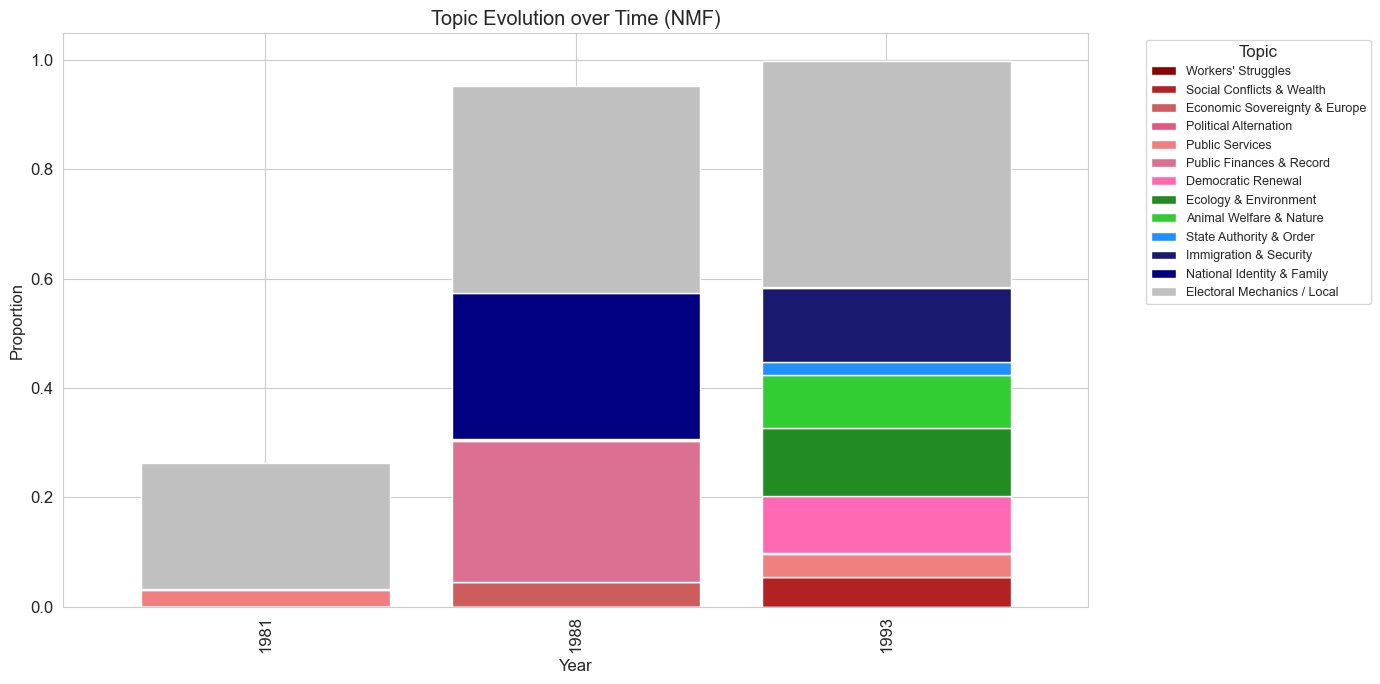

In [32]:
fig, ax = plt.subplots(figsize=(14, 7))

ordered_cols = get_ordered_columns(NMF_THEME_MAP)
ordered_colors = get_ordered_colors(NMF_THEME_MAP)

ct = pd.crosstab(df['annee'], df['nmf_unified'], normalize='index')
ct = ct.reindex(columns=ordered_cols, fill_value=0)

ct.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=ordered_colors)
ax.set_title('Topic Evolution over Time (NMF)')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion')
ax.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('plots/nmf_temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

Tracking topic proportions across the three elections reveals a political landscape in transformation. The **Immigration/Security** topic is virtually absent in 1981, begins to appear in 1988, and becomes a major theme by 1993 — directly mirroring the electoral rise of the Front National. Conversely, the **Political Alternation** topic (dominated by references to Mitterrand, the Union de la Gauche, and governmental change) is massive in 1981 and 1988 but shrinks in 1993 as the Left loses power. The **Ecology** topic appears almost exclusively in 1993, coinciding with the Entente des Écologistes (Verts + Génération Écologie). The **Workers' Struggles** topic declines steadily from 1981 to 1993, consistent with the weakening of class-based political rhetoric in favour of more technocratic discourse.

## 2.2 - Topics and political family

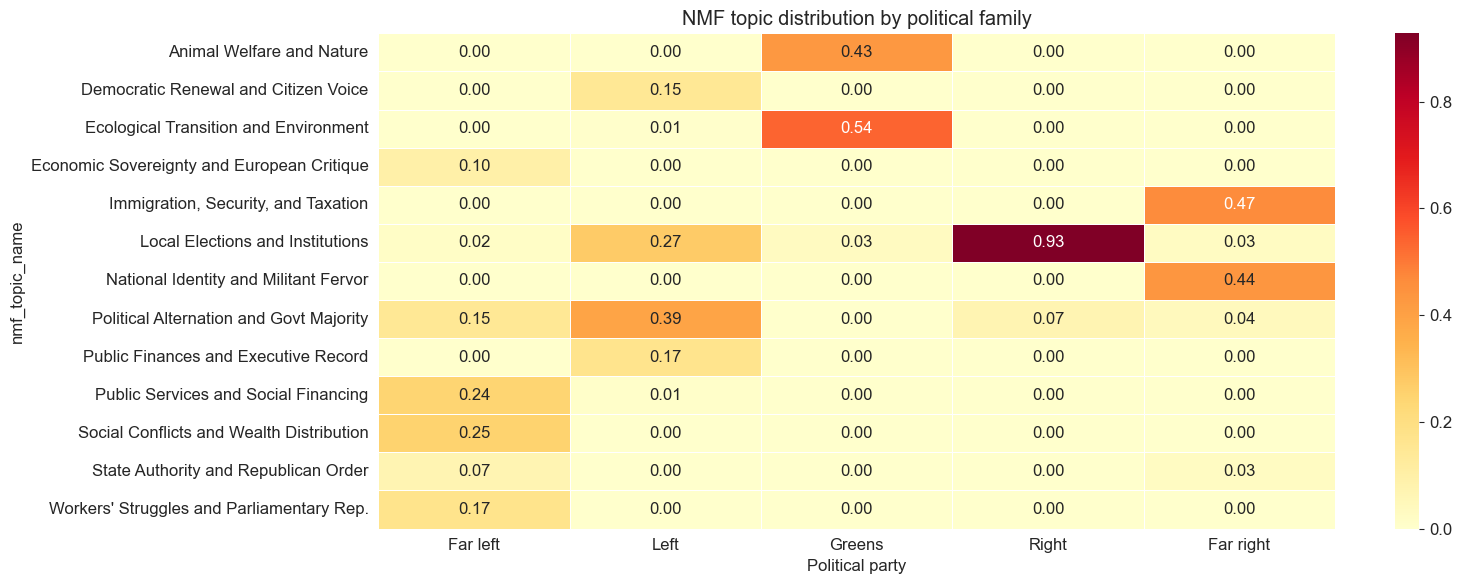

In [33]:
ct_nmf = pd.crosstab(df['famille'], df['nmf_topic_name'], normalize='index')
ct_nmf = ct_nmf.reindex(FAMILY_ORDER)

plt.figure(figsize=(16, 6))
sns.heatmap(ct_nmf.T, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('NMF topic distribution by political family')
plt.xlabel('Political party')
plt.tight_layout()
plt.savefig('plots/nmf_topics_famille.png', dpi=150, bbox_inches='tight')
plt.show()

# ct_lda = pd.crosstab(df['famille'], df['lda_topic_name'], normalize='index')
# ct_lda = ct_lda.reindex(FAMILY_ORDER)

# plt.figure(figsize=(16, 6))
# sns.heatmap(ct_lda.T, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
# plt.title('LDA topic distribution by political family')
# plt.xlabel('Political party')
# plt.tight_layout()
# plt.savefig('plots/lda_topics_famille.png', dpi=150, bbox_inches='tight')
# plt.show()

We compute P(topic | family) via normalised cross-tabulation for each of the five political families. Both LDA and NMF reveal sharp partisan segmentation. The **Far right** concentrates almost exclusively on two topics: Immigration/Security (0.47 in NMF) and National Identity/Militant Fervor (0.44), together accounting for over 90% of its discourse. The **Greens** similarly concentrate on Ecological Transition (0.55) and Animal Welfare (0.42). The **Far left** is more dispersed but centres on Social Conflicts/Wealth Distribution (0.25), Public Services (0.24), and Workers' Struggles (0.17). By contrast, the **Left** and **Right** are thematically broader: the Left spreads across Political Alternation (0.40), Local Elections (0.27), and Public Finances (0.17), while the Right is overwhelmingly captured by the Local Elections and Institutions topic (0.93 in NMF), reflecting the dominance of notability-based campaigning in conservative manifestos.

## Topic specialization by party - over/under representation : statistical testing

To move beyond raw distributions and identify statistically meaningful over-representation, we compute the specialisation ratio P(topic | family) / P(topic) for each family–topic pair. A ratio above 1.5 indicates significant over-representation; below 0.7, significant under-representation. The results are striking in their magnitude.


Calculating specialization by political family...


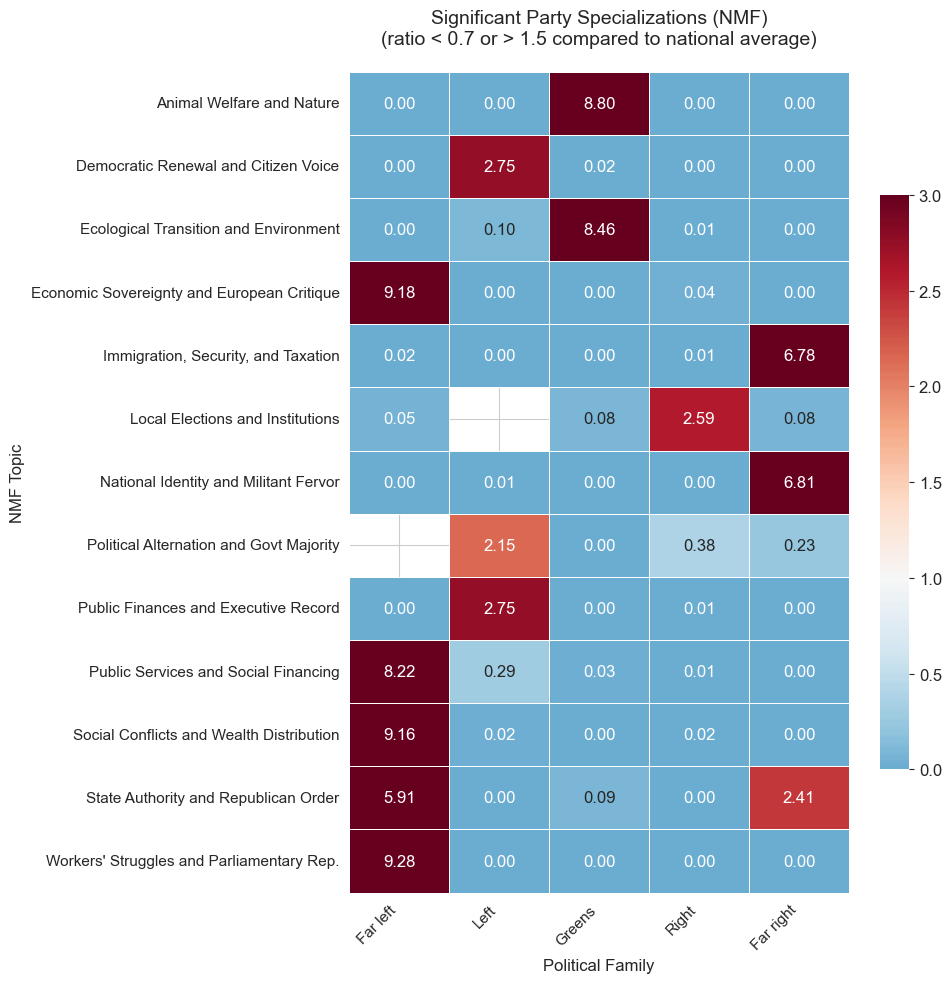

In [34]:
# ============================================================
# 2. Party Specialization (Over/Under-representation Ratio)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nCalculating specialization by political family...")

# ----------------- NMF -----------------
topic_marginal_nmf = df['nmf_topic_name'].value_counts(normalize=True).sort_index()
ct_norm_nmf = pd.crosstab(df['famille'], df['nmf_topic_name'], normalize='index')
ct_norm_nmf = ct_norm_nmf.reindex(FAMILY_ORDER)  # Ensure consistent family order
specialization_nmf = ct_norm_nmf.div(topic_marginal_nmf, axis=1)
mask_nmf = (specialization_nmf > 0.7) & (specialization_nmf < 1.5)

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(specialization_nmf.T, annot=True, fmt='.2f', cmap='RdBu_r',
            center=1.0, linewidths=0.5, ax=ax, mask=mask_nmf.T, vmin=0, vmax=3,
            cbar_kws={"shrink": 0.7}) 

ax.set_title('Significant Party Specializations (NMF)\n(ratio < 0.7 or > 1.5 compared to national average)', 
             fontsize=14, pad=20)
ax.set_xlabel('Political Family', fontsize=12)
ax.set_ylabel('NMF Topic', fontsize=12)


plt.xticks(rotation=45, ha='right', fontsize=11) 
plt.yticks(rotation=0, fontsize=11)       

plt.tight_layout()
plt.savefig('plots/nmf_party_specialization.png', dpi=150, bbox_inches='tight')
plt.show()


# ----------------- LDA -----------------
# topic_marginal_lda = df['lda_topic_name'].value_counts(normalize=True).sort_index()
# ct_norm_lda = pd.crosstab(df['famille'], df['lda_topic_name'], normalize='index')
# ct_norm_lda
# specialization_lda = ct_norm_lda.div(topic_marginal_lda, axis=1)
# mask_lda = (specialization_lda > 0.7) & (specialization_lda < 1.5)

# fig, ax = plt.subplots(figsize=(10, 10))

# # Transposition (.T)
# sns.heatmap(specialization_lda.T, annot=True, fmt='.2f', cmap='RdBu_r',
#             center=1.0, linewidths=0.5, ax=ax, mask=mask_lda.T, vmin=0, vmax=3,
#             cbar_kws={"shrink": 0.7})

# ax.set_title('Significant Party Specializations (LDA)\n(ratio < 0.7 or > 1.5 compared to national average)', 
#              fontsize=14, pad=20)
# ax.set_xlabel('Political Family', fontsize=12)
# ax.set_ylabel('LDA Topic', fontsize=12)

# plt.xticks(rotation=45, ha='right', fontsize=11)
# plt.yticks(rotation=0, fontsize=11)

# plt.tight_layout()
# plt.savefig('plots/lda_party_specialization.png', dpi=150, bbox_inches='tight') 
# plt.show()

The **Far left** shows extreme specialisation on Workers' Struggles (9.27×), Social Conflicts (9.15×), Economic Sovereignty (9.17×), and Public Services (8.21×) — all virtually absent from other families. The **Far right** is equally extreme on Immigration (6.77×) and National Identity (6.80×). The **Greens** reach the highest single ratio on Animal Welfare (8.89×) and Ecological Transition (8.49×). Crucially, these specialisations are almost perfectly complementary: topics that are strongly over-represented for one family show ratios near zero for all others, suggesting that French political discourse in this period was highly segmented, with minimal thematic overlap between the political extremes.

## 2.3 - Topics by election (year) and by party 
The triple cross-tabulation (topic × family × year) reveals that partisan specialisation is not static.


Generating dynamic specialization (Party × Year)...


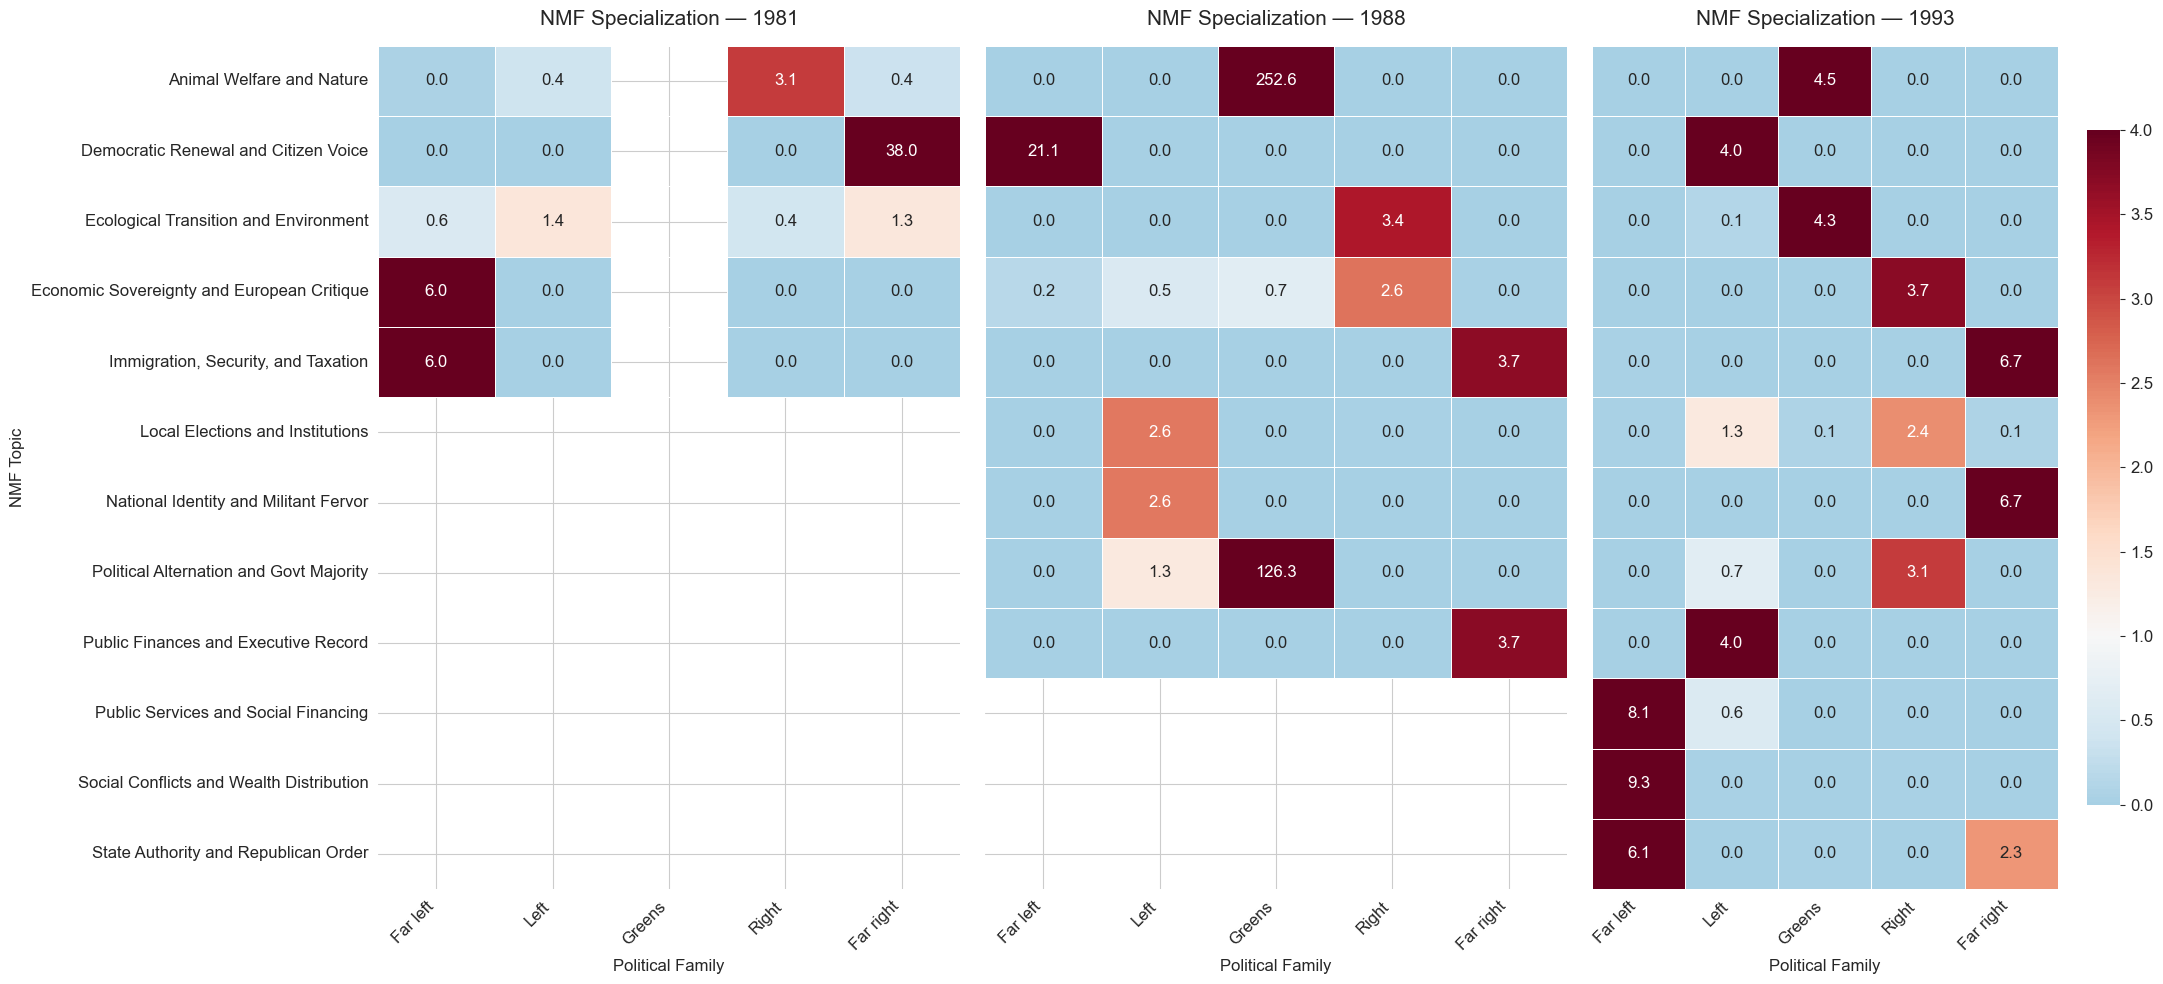

In [35]:
print("\nGenerating dynamic specialization (Party × Year)...")

fig, axes = plt.subplots(1, 3, figsize=(22, 10), sharey=True)
years = [1981, 1988, 1993]

for i, year in enumerate(years):

    df_year = df[(df['annee'] == year) & (df['famille'] != 'Autre / Inconnu')]
    
    if df_year.empty:
        continue
        
    marg_year = df_year['nmf_topic_name'].value_counts(normalize=True).sort_index()
    ct_year = pd.crosstab(df_year['famille'], df_year['nmf_topic_name'], normalize='index')
    ct_year = ct_year.reindex(FAMILY_ORDER)  # Ensure consistent family order

    ct_year = ct_year.reindex(columns=marg_year.index, fill_value=0)
    spec_year = ct_year.div(marg_year, axis=1)
    
    sns.heatmap(spec_year.T, annot=True, fmt='.1f', cmap='RdBu_r',
                center=1.0, linewidths=0.5, ax=axes[i], vmin=0, vmax=4,
                cbar=(i == 2), 
                cbar_kws={"shrink": 0.8} if i == 2 else None)
    
    axes[i].set_title(f'NMF Specialization — {year}', fontsize=15, pad=15)
    axes[i].set_xlabel('Political Family', fontsize=12)
    

    axes[i].tick_params(axis='x', rotation=45)
    for label in axes[i].get_xticklabels():
        label.set_ha('right')
    
    if i == 0:
        axes[i].set_ylabel('NMF Topic', fontsize=12)
        axes[i].tick_params(axis='y', rotation=0) 
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('plots/nmf_specialization_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

# print("\nGenerating dynamic specialization (Party × Year) for LDA...")

# fig, axes = plt.subplots(1, 3, figsize=(22, 10), sharey=True)
# years = [1981, 1988, 1993]

# for i, year in enumerate(years):

#     df_year = df[(df['annee'] == year) & (df['famille'] != 'Autre / Inconnu')]
    
#     if df_year.empty:
#         continue

#     marg_year = df_year['lda_topic_name'].value_counts(normalize=True).sort_index()
#     ct_year = pd.crosstab(df_year['famille'], df_year['lda_topic_name'], normalize='index')
#     ct_year = ct_year.reindex(FAMILY_ORDER)
#     ct_year = ct_year.reindex(columns=marg_year.index, fill_value=0)
#     spec_year = ct_year.div(marg_year, axis=1)
#     sns.heatmap(spec_year.T, annot=True, fmt='.1f', cmap='RdBu_r',
#                 center=1.0, linewidths=0.5, ax=axes[i], vmin=0, vmax=4,
#                 cbar=(i == 2), 
#                 cbar_kws={"shrink": 0.8} if i == 2 else None)
    
#     axes[i].set_title(f'LDA Specialization — {year}', fontsize=15, pad=15)
#     axes[i].set_xlabel('Political Family', fontsize=12)
    
#     axes[i].tick_params(axis='x', rotation=45)
#     for label in axes[i].get_xticklabels():
#         label.set_ha('right')
    
#     if i == 0:
#         axes[i].set_ylabel('LDA Topic', fontsize=12)
#         axes[i].tick_params(axis='y', rotation=0) 
#     else:
#         axes[i].set_ylabel('')

# plt.tight_layout()
# plt.savefig('plots/lda_specialization_by_year.png', dpi=150, bbox_inches='tight')
# plt.show()

In 1981, the **Far left** dominates Economic Sovereignty (6.0×) and Immigration (6.0×) — the latter reflecting far-left anti-capitalist framing of migration, not the far-right framing that would emerge later. By 1993, Immigration has shifted entirely to the **Far right** (6.6×), while the Far left's specialisation has concentrated on Workers' Struggles (9.3×) and Social Conflicts (9.3×). The **Right**'s profile also evolves: relatively diffuse in 1981, it sharpens by 1993 around Local Elections (2.4×), Economic Sovereignty (3.7×), and Political Alternation (3.1×), reflecting the RPR-UDF coalition's broader agenda. Some extreme ratios in 1988 (e.g., Greens at 252.8× on Animal Welfare, 126.4× on Political Alternation) reflect the very small number of Green candidates that year, making the ratios statistically unstable but directionally informative.

## 2.4 - Topics by candidate characteristics

### Correlation between topics and gender


Cross-analyzing Gender × Topics...


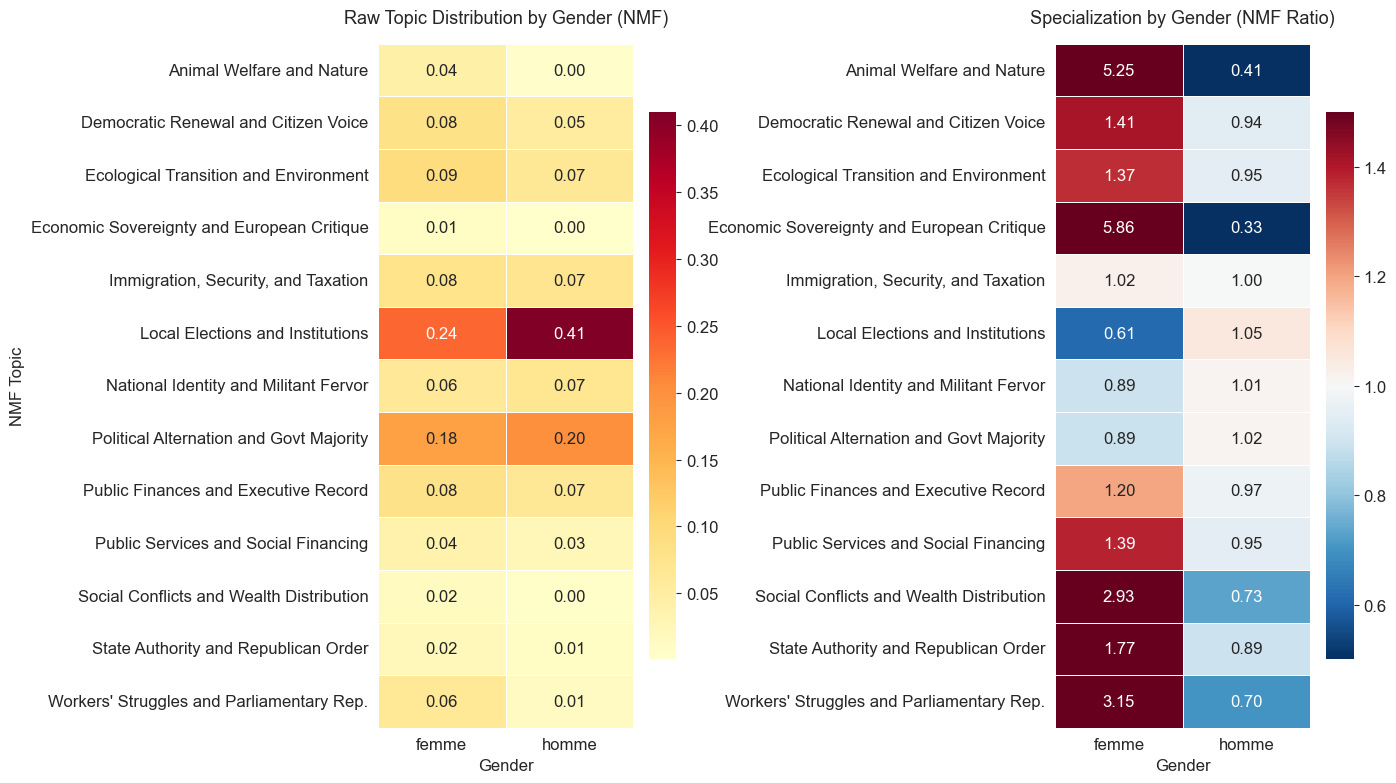

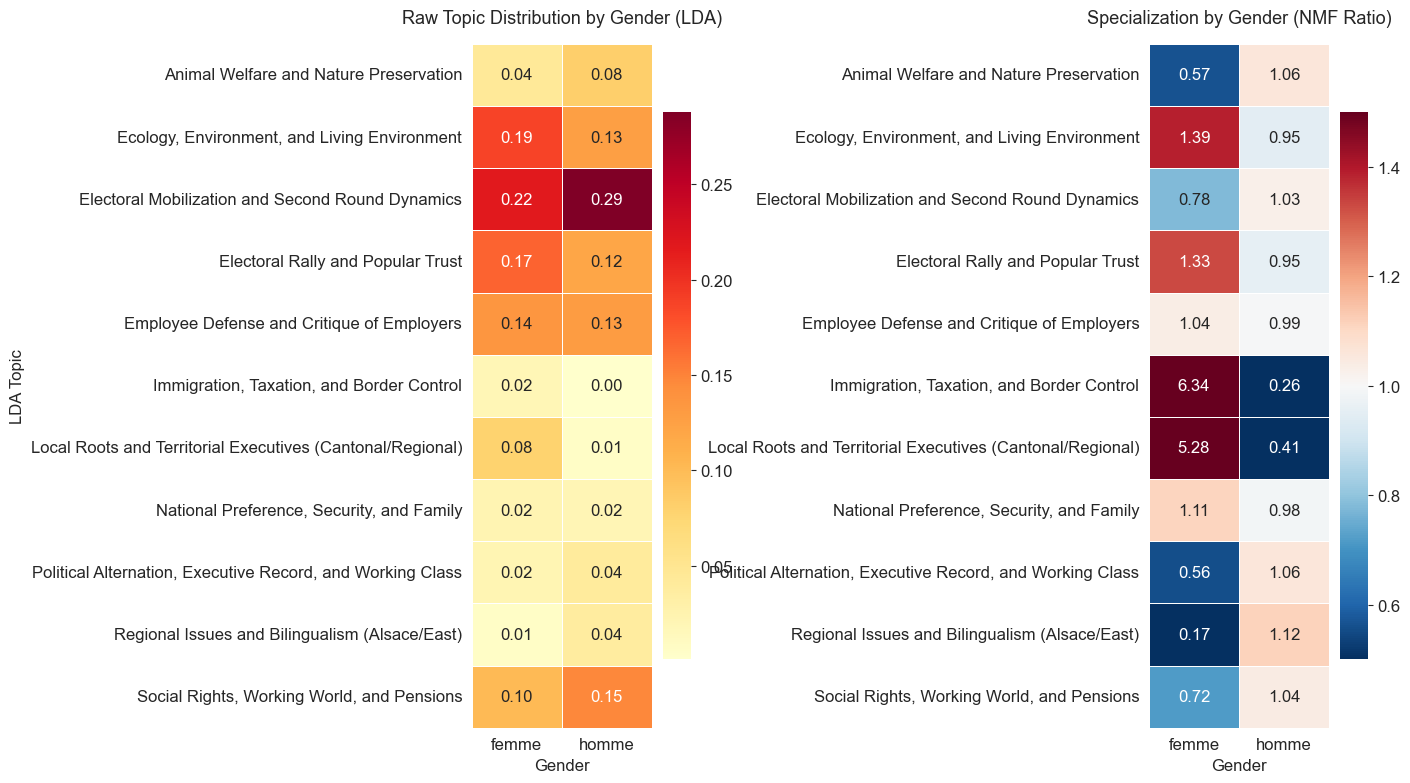

In [38]:
# ============================================================
# 4. Cross-analysis: Gender × NMF & LDA Topics
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'titulaire-sexe' in df.columns:
    print("\nCross-analyzing Gender × Topics...")

    df_gender = df[df['titulaire-sexe'].isin(['homme', 'femme'])]
    
    ct_gender_nmf = pd.crosstab(df_gender['titulaire-sexe'], df_gender['nmf_topic_name'], normalize='index')
    topic_marginal_gender_nmf = df_gender['nmf_topic_name'].value_counts(normalize=True).sort_index()
    spec_gender_nmf = ct_gender_nmf.div(topic_marginal_gender_nmf, axis=1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))

    sns.heatmap(ct_gender_nmf.T, annot=True, fmt='.2f', cmap='YlOrRd', 
                linewidths=0.5, ax=axes[0], cbar_kws={"shrink": 0.8})
    axes[0].set_title('Raw Topic Distribution by Gender (NMF)', fontsize=13, pad=15)
    axes[0].set_ylabel('NMF Topic', fontsize=12)
    axes[0].set_xlabel('Gender', fontsize=12)
    axes[0].tick_params(axis='y', rotation=0) 

    sns.heatmap(spec_gender_nmf.T, annot=True, fmt='.2f', cmap='RdBu_r', center=1.0, 
                linewidths=0.5, ax=axes[1], vmin=0.5, vmax=1.5, cbar_kws={"shrink": 0.8})
    axes[1].set_title('Specialization by Gender (NMF Ratio)', fontsize=13, pad=15)
    axes[1].set_ylabel('') 
    axes[1].set_xlabel('Gender', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('plots/nmf_topics_by_gender.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --------------------------------------------------------
    # PARTIE LDA
    # --------------------------------------------------------
    ct_gender_lda = pd.crosstab(df_gender['titulaire-sexe'], df_gender['lda_topic_name'], normalize='index')
    topic_marginal_gender_lda = df_gender['lda_topic_name'].value_counts(normalize=True).sort_index()
    spec_gender_lda = ct_gender_lda.div(topic_marginal_gender_lda, axis=1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    
    sns.heatmap(ct_gender_lda.T, annot=True, fmt='.2f', cmap='YlOrRd', 
                linewidths=0.5, ax=axes[0], cbar_kws={"shrink": 0.8})
    axes[0].set_title('Raw Topic Distribution by Gender (LDA)', fontsize=13, pad=15)
    axes[0].set_ylabel('LDA Topic', fontsize=12)
    axes[0].set_xlabel('Gender', fontsize=12)
    axes[0].tick_params(axis='y', rotation=0)
    
    sns.heatmap(spec_gender_lda.T, annot=True, fmt='.2f', cmap='RdBu_r', center=1.0, 
                linewidths=0.5, ax=axes[1], vmin=0.5, vmax=1.5, cbar_kws={"shrink": 0.8})
    axes[1].set_title('Specialization by Gender (NMF Ratio)', fontsize=13, pad=15)
    axes[1].set_ylabel('')
    axes[1].set_xlabel('Gender', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('plots/lda_topics_by_gender.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("\nColumn 'titulaire-sexe' not found. Skipping cross-analysis by gender.")

Cross-tabulating topics with candidate gender reveals a systematic pattern confirmed by both LDA and NMF. **Women candidates** are over-represented on Animal Welfare (5.25×), Workers' Struggles (3.15×), Social Conflicts (2.93×), Economic Sovereignty (5.87×), and State Authority (1.75×). Men dominate the **Local Elections** topic (women at 0.61×), consistent with the incumbency advantage of male *notables* who emphasise their local mandates. However, the gender imbalance in the corpus (women represent a small minority of candidates across all three elections) means these ratios should be interpreted cautiously. The over-representation of women on far-left and Green topics likely reflects the higher proportion of female candidates in those parties rather than a gender-specific thematic preference independent of party.


## Conclusion

Despite the inherent limitations of unsupervised topic modeling : diffuse topics in LDA, sensitivity to K, OCR noise, we can be happy as the cross-analyses produced consistent and historically plausible results across all three methods. The thematic specialisations recovered by NMF align with known political positions: the Far right concentrates on immigration and national identity, the Far left on workers' struggles and wealth redistribution, and the Greens on ecology and animal welfare. These correspondences serve as strong sanity checks, confirming that the extracted topics capture genuine political signal rather than corpus artifacts.

The volume of cross-analyses performed (by party, by year, by gender) and across all combinations makes it difficult to be exhaustive in interpretation. Each heatmap contains dozens of data points worthy of discussion. However, the most valuable insight arguably lies in the **temporal dynamics of partisan discourse**: the rise of immigration as a dominant theme from 1981 to 1993, the decline of class-based rhetoric on the Left, the emergence of ecology as a structured political discourse, and the shift of the Right from economic liberalism to a broader institutional and law-and-order agenda. These thematic trajectories, detected automatically from 12,500 OCR-transcribed documents, faithfully mirror the political transformations of the Mitterrand era as documented by historians —suggesting that topic modeling, despite its imperfections, is a powerful tool for large-scale political text analysis.